### **TP2_Data_Analysis_Notebook**

During this session we will work on real VSDI images  obtained from the primary somatosensory cortex from the rat

I invite you to read the following paper 
**[Grinvald (2004) VSDI a new era in functional imaging of cortical dynamics](http://wexler.free.fr/library/files/grinvald%20(2004)%20vsdi.%20a%20new%20era%20in%20functional%20imaging%20of%20cortical%20dynamics.pdf)**


**Description of the experiment :** 

In the anasthetized rat, you are interested in studying the dynamic of tactile evoked responses in the primary somatosensory cortex.

Brief tactile stimulations (duration of a stimulus = 20 ms) were randomly applied on the finger tip (digit 2,3,4 or 5) of the rat forehand, about 1 stimulus per 20 second. 

Emitted VSDI fluorescence was recorded. During a trial, one image was acquired every 3 ms, 256 times. One trial = 256 images each 3ms then 768 ms of duration for a trial.

As usual, like for **any imaging method**, one has to **compare a 'test' trial (with stimulus) to a control trial**

Alternatively, stimulation and control trials were acquired. 

A file can contain data from a stimulation trial or a control trial (acquisition of the same amount of images without tactile stimulation)

For example the file named T1-B2R10-0419-616 contains the images of a trial with a stimulation while the file named T1-B2R10-0419-617 contains control images with stimulation (acquisition of the same amount of images without tactile stimulation).


During a trial with stimulation, the stimulus was applied 100 ms after beginning of image acquisition. The stimulus was then applied at frame (image) 33. 


Each file named "T1-B2R10-0419-..." contains the same variable:

- **Evok** : Fluorescence signal for the 10 000 pixels of each 256 images of one acquisition (10 000 pixels $*$ 256 images)
            
            
The file MANIP120419_2 contains : 

- **Block** : stimulus of the list of trial



### **Starting**

First step, 
**Drop all the needed file into your main directory**

**Just run the following section** in order to open and convert the lists Evok into a 100 pixels $*$ 100 pixels $*$ 256 images array, for a stimulus trial and a control trial, to open the file containing the identification of the trial (which finger had been stimulated) and to open cortex image

Text(0.5, 1.0, 'Cortex')

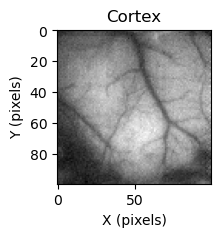

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
from scipy.io import loadmat
import matplotlib as mpl
mpl.rcParams['font.size'] =10

DataUnit=loadmat('MANIP120419_2')  
ListCond=DataUnit["block"]
ListCond=ListCond[0]

#np.where(ListCond=='A3_1_0_100ms')
# [ 6, 18, 20, 28, 30, 40, 54, 66, 70, 88]

fileIDinit=616
trialID=1
fileID=fileIDinit+2*trialID-2

##Open files and converted into a 100 pixels * 100 pixels * 256 images array
Data=loadmat('T'+str(trialID)+'-B2R10-0419-'+str(fileID))  
Stim=Data["Evok"].reshape((100,100,255))
Data=loadmat('T'+str(trialID)+'-B2R10-0419-'+str(fileID+1))  
Control=Data["Evok"].reshape((100,100,255))
Cortex=loadmat('GREEN_MANIP120419')  
Cortex=Cortex["gr"]

fig = plt.figure( figsize=(2,2))

plt.imshow(Cortex)
plt.xlabel('X (pixels)')
plt.ylabel('Y (pixels)')
plt.title('Cortex')



*Stim* is now a 3D matrix of 100 $*$ 100 $*$ 256. 256 images of 100 $*$ 100 pixels.

Same applies for *Control*

Then *Stim[:,:,0]* is the first image of *Stim*.
*Stim[50,50,:]* will give you the signal over time for the pixel in the center of the image.

**To do list:**

* Visualize the image 40 of the *stim* trial and the image 40 of the *control* trial (use imshow) - 2 min - 
* For one choosen pixel, plot the signal (fluorescence F) as a function of time (from 0 to 256 images) for the stim trial and the control trial on the same plot with different color - 2 min - 
* Explain why it is important to compare both. 
* Calculate a new 3DArray with is the result of (Stim-Control)/Control. This ratio called  ***DF/F***. - 5 min - 
* For one choosen pixel, plot the *DF/F* as a function of time (from 0 to 256 images) - 2 min - 
* Visualize the image 40 of *DF/F* - 2 min -
* Using a gaussian filter, filter the images  (function : gaussian_filter), visualize the image 40 of *DF/F* filtered with a kernel of 2,3,4 and 5 (make a subplot of 1 line and 4 plots) - 20 min -
* On one figure, show on the 2 rows (subplot(2,10)) - 10 min -
    *  10 following *DF/F*  non filtered images (image 37 to 46) on one row
    *  10 following *DF/F*  filtered images (image 37 to 46) on a second row
* plot the *DF/F* as a function of time for a pixel located the region of activation and plot on the same axes, the mean *DF/F* of a group of pixel (ROI : region of interest)  - 15 min -



**RAW images**

**Visualize the image 40 of the stim trial and the image 40 of the control trial (use imshow)** - 2 min - 

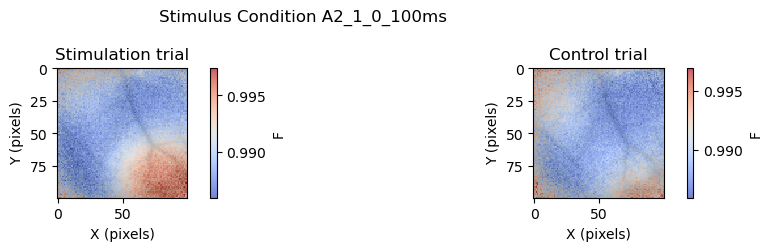

In [2]:
### image to see one out of 256 frame = image n° x

frame=40

fig = plt.figure( figsize=(10,4))
ax1 = fig.add_subplot(2,2,1)
ax2 = fig.add_subplot(2,2,2)
pos1=ax1.imshow(Cortex,alpha=1)
pos2=ax2.imshow(Cortex,alpha=1)
pos1=ax1.imshow(Stim[:,:,frame], cmap='coolwarm', interpolation='none',alpha=0.7)
pos2=ax2.imshow(Control[:,:,frame], cmap='coolwarm', interpolation='none',alpha=0.7)


ax1.set_xlabel('X (pixels)'),ax2.set_xlabel('X (pixels)')
ax1.set_ylabel('Y (pixels)'),ax2.set_ylabel('Y (pixels)')
ax1.set_title('Stimulation trial'),ax2.set_title('Control trial')
fig.colorbar(pos1, ax=ax1,label='F')
fig.colorbar(pos2, ax=ax2,label='F')
fig.suptitle('Stimulus Condition ' +ListCond[2*trialID-2][0])
plt.tight_layout()

**Compute DF/F and plot RAW signal vs DF/F**

**For one choosen pixel, plot the signal (fluorescence F) as a function of time (from 0 to 256 images) for the stim trial and the control trial on the same plot with different color** - 2 min - 

**Explain why it is important to compare both.**

**Calculate a new 3DArray with is the result of (Stim-Control)/Control. This ratio called DF/F.** - 5 min -

**For one choosen pixel, plot the DF/F as a function of time (from 0 to 256 images)** - 2 min - 

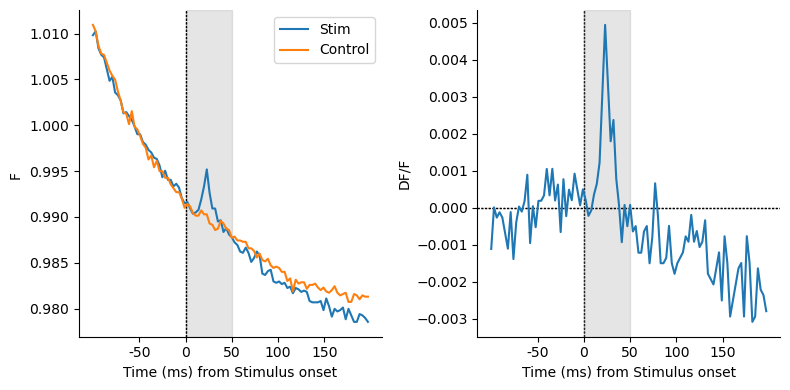

In [3]:


fig, axs = plt.subplots(1, 2, figsize=(8,4))

axs[0].plot(Stim[70,70,0:100], label = 'Stim')
axs[0].plot(Control[70,70,0:100], label = 'Control')

axs[0].set_xlabel('Time (ms) from Stimulus onset')
axs[0].set_ylabel('F ')
axs[0].legend()
axs[0].spines['right'].set_visible(False)
axs[0].spines['top'].set_visible(False)
axs[0].set_xticks(ticks=[50/3,100/3,150/3,200/3,250/3], labels=['-50','0','50','100','150'])
axs[0].axvspan(100/3,150/3,alpha=0.2,color='gray')
axs[0].axvspan(100/3,100/3,color = 'k',linestyle =':')

#####  DF/F
dF=(Stim[:,:,:]-Control[:,:,:])/Control[:,:,:]
#######

axs[1].plot((Stim[70,70,0:100]-Control[70,70,0:100])/Control[70,70,0:100])

axs[1].set_xlabel('Time (ms) from Stimulus onset')
axs[1].set_ylabel('DF/F')
axs[1].spines['right'].set_visible(False)
axs[1].spines['top'].set_visible(False)
axs[1].axvspan(100/3,100/3,color = 'k', label = 'axvline - full height',linestyle =':')
axs[1].set_xticks(ticks=[50/3,100/3,150/3,200/3,250/3], labels=['-50','0','50','100','150'])
axs[1].axvspan(100/3,150/3,alpha=0.2,color='gray')
axs[1].axhspan(0,0,color = 'k',linestyle =':')

plt.tight_layout()


**Visualize the image 40 of *DF/F*** - 2 min -


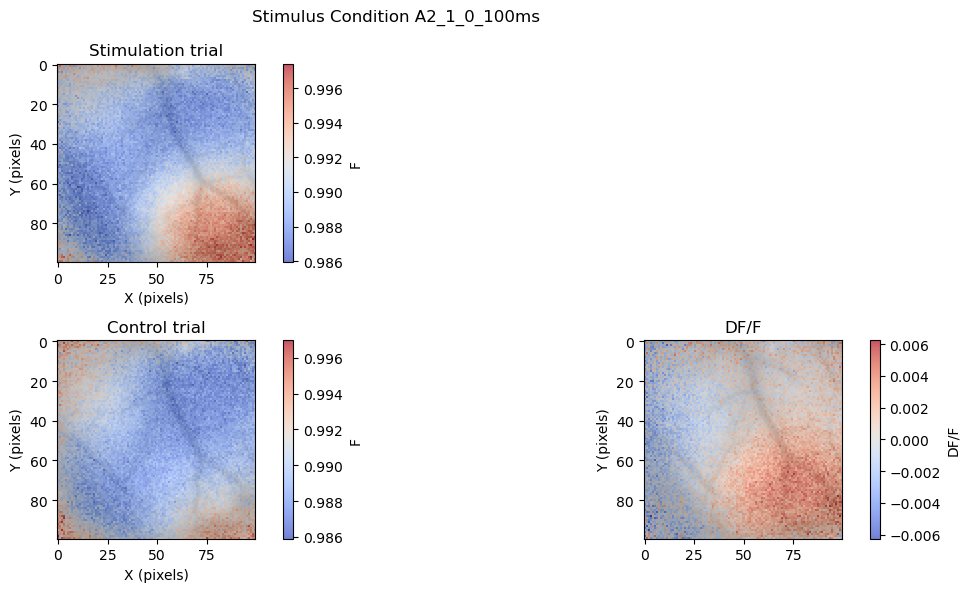

In [4]:

fig = plt.figure( figsize=(12,6))
ax1 = fig.add_subplot(2,2,1)
ax2 = fig.add_subplot(2,2,3)
ax3 = fig.add_subplot(2,2,4)

pos1=ax1.imshow(Cortex,alpha=1)
pos1=ax1.imshow(Stim[:,:,frame], cmap='coolwarm', interpolation='none',alpha=0.7)

pos2=ax2.imshow(Cortex,alpha=1)
pos2=ax2.imshow(Control[:,:,frame], cmap='coolwarm', interpolation='none',alpha=0.7)

pos3=ax3.imshow(Cortex,alpha=1)
pos3=ax3.imshow(dF[:,:,frame], cmap='coolwarm', interpolation='none',alpha=0.7)

ax1.set_xlabel('X (pixels)'),ax2.set_xlabel('X (pixels)'),ax3.set_ylabel('Y (pixels)')
ax1.set_ylabel('Y (pixels)'),ax2.set_ylabel('Y (pixels)'),ax3.set_ylabel('Y (pixels)')
ax1.set_title('Stimulation trial'),ax2.set_title('Control trial'),ax3.set_title('DF/F')
fig.colorbar(pos1, ax=ax1,label='F')
fig.colorbar(pos2, ax=ax2,label='F')
fig.colorbar(pos3, ax=ax3,label='DF/F')
fig.suptitle('Stimulus Condition ' +ListCond[0][0])
plt.tight_layout()


**Using a gaussian filter, filter the images  (function : gaussian_filter), visualize the image 40 of *DF/F* filtered with a kernel of 2,3,4 and 5 (make a subplot of 1 line and 4 plots)** - 20 min -

#### **Filter the images with gaussians filter**

Define the Sigma depending on the level of filtering 

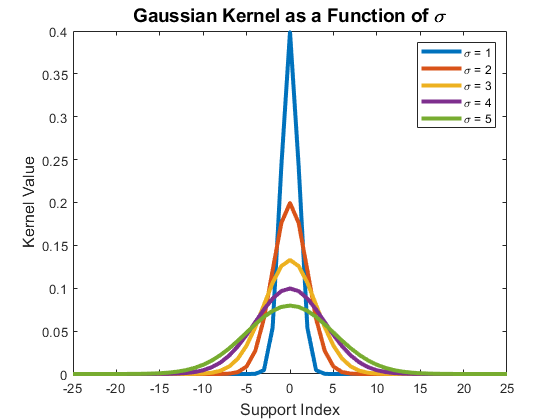

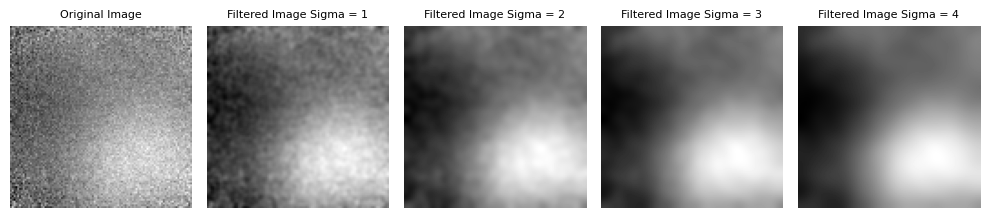

In [5]:
from scipy.ndimage import gaussian_filter

image=dF[:,:,frame]

fig, axs = plt.subplots(1, 5, figsize=(10, 5))

axs[0].imshow(image, cmap='gray')

axs[0].set_title('Original Image',fontsize=8)
axs[0].axis('off')

for i in range(1,5):
    sigma = i
    filtered_image = gaussian_filter(image, sigma=sigma)

    axs[i].imshow(filtered_image, cmap='gray')
    
    axs[i].set_title('Filtered Image Sigma = '+str(sigma),fontsize=8)
    axs[i].axis('off')
    
plt.tight_layout()

plt.show()



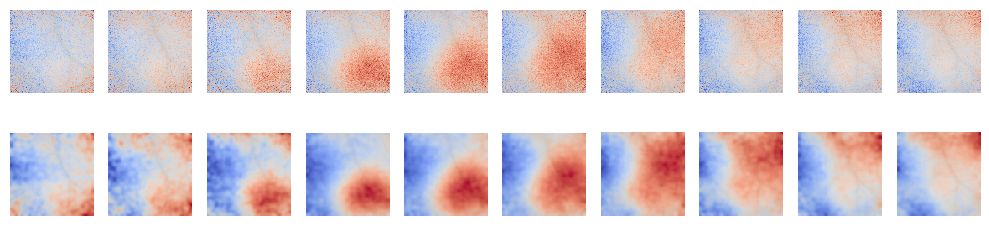

In [18]:
## Show 10 consecutive images

sigma=2

fig, axs = plt.subplots(2, 10, sharey='row',figsize=(10,3))
subplotid=0
for i in range(37,47):
    
    axs[0][subplotid].imshow(Cortex,alpha=1)
    axs[0][subplotid].imshow(dF[:,:,i], cmap='coolwarm', interpolation='none',alpha=0.9)
    axs[0][subplotid].set_xlabel('X (pixels)')
    axs[0][subplotid].axis('off')
    
## Show 10 consecutive images filtered

    filtered_image = gaussian_filter(dF[:,:,i], sigma=sigma)
    
    axs[1][subplotid].imshow(Cortex,alpha=1)
    axs[1][subplotid].imshow(filtered_image, cmap='coolwarm', interpolation='none',alpha=0.9)

    axs[1][subplotid].set_xlabel('X (pixels)')
    axs[1][subplotid].axis('off')
    subplotid=subplotid+1
    
plt.tight_layout()




**Plot the *DF/F* as a function of time for a pixel located the region of activation and plot on the same axes, the mean *DF/F* of a group of pixel (ROI : region of interest)  - 15 min -**

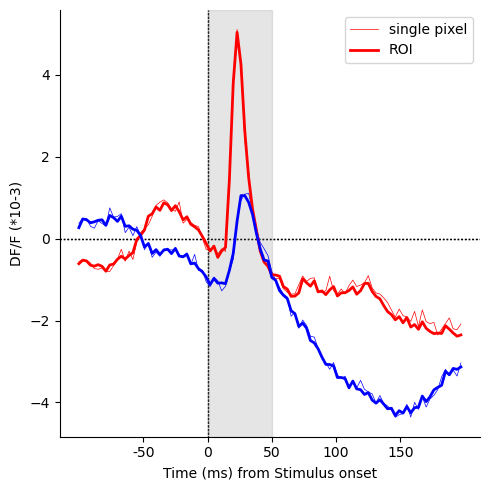

In [14]:


dFfilt=np.zeros((100,100,255))

for i in range(255):
    dFfilt[:,:,i]=gaussian_filter(dF[:,:,i], sigma=sigma)

fig, axs = plt.subplots(1, 1,figsize=(5,5))

axs.plot(dFfilt[70,70,0:100]*1000,color='red',lw=0.5,label='single pixel')
axs.plot(dFfilt[40,40,0:100]*1000,color='blue',lw=0.5)

axs.set_xlabel('Time (ms) from Stimulus onset')
axs.set_ylabel('DF/F (*10-3)')
axs.spines['right'].set_visible(False)
axs.spines['top'].set_visible(False)
axs.axvspan(100/3,100/3,color = 'k',linestyle =':')
axs.set_xticks(ticks=[50/3,100/3,150/3,200/3,250/3], labels=['-50','0','50','100','150'])
axs.axhspan(0,0,color = 'k',linestyle =':')


ROI=[]
ROI2=[]
for i in range(dFfilt.shape[2]):
    ROI.append(np.mean(dFfilt[60:80,60:80,i])*1000)
    ROI2.append(np.mean(dFfilt[30:50,30:50,i])*1000)


axs.plot(ROI[0:100],color='red',lw=2,label='ROI')
axs.plot(ROI2[0:100],color='blue',lw=2)


axs.axvspan(100/3,150/3,alpha=0.2,color='gray')

axs.legend()

plt.tight_layout()

